In [67]:
import torch
from torch import nn
from torch.nn import functional as F

triplet_x = torch.randint(0, 2, (10000, 256)).bool()
triplets = torch.randint(0, 256, (1, 3))
y = torch.zeros(10000, dtype=torch.bool)
for i, triplet in enumerate(triplets):
    # y = y | (triplet_x[:, triplet[0]] & ~triplet_x[:, triplet[1]] & triplet_x[:, triplet[2]])
    y = y | (triplet_x[:, triplet[0]] & ~triplet_x[:, triplet[1]])

triplet_x = triplet_x.long()
y = y.long()

In [68]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Split data into training and testing sets (80/20 split)
dataset_size = len(triplet_x)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

# Create dataset and split
dataset = TensorDataset(triplet_x, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Input dimension: {triplet_x.shape[1]}")

Training samples: 8000
Test samples: 2000
Input dimension: 256


In [69]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:x.size(0), :]

In [70]:
class BinaryTransformer(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.1):
        super(BinaryTransformer, self).__init__()
        
        self.d_model = d_model
        self.input_dim = input_dim
        
        # Input embedding for binary sequences
        self.input_embedding = nn.Embedding(2, d_model)
        # self.positional_encoding = PositionalEncoding(d_model, max_len=input_dim)
        self.positional_encoding = nn.Parameter(torch.zeros(input_dim, d_model))
        nn.init.normal_(self.positional_encoding, mean=0.0, std=0.02)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layers
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, 1),
        )
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape
        # x = x.unsqueeze(-1)
        x = self.input_embedding(x) # (batch_size, seq_len, d_model)
        x = x + self.positional_encoding.reshape(1, self.input_dim, self.d_model)
        # Add positional encoding
        # x = x.transpose(0, 1)  # (seq_len, batch_size, d_model)
        # x = self.positional_encoding(x)
        # x = x.transpose(0, 1)  # (batch_size, seq_len, d_model)
        
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1) 
        output = self.classifier(x) 
        return output.squeeze(-1)  # (batch_size,)

In [79]:
input_dim = triplet_x.shape[1]
d_model = 128
nhead = 8
num_layers = 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BinaryTransformer(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers
).to(device)
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
output = model(x_batch)
print(y_batch, output)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0], device='cuda:0') tensor([-0.2436, -0.2385, -0.2352, -0.2356, -0.2339, -0.2184, -0.2394, -0.2385,
        -0.2208, -0.2498, -0.2387, -0.2326, -0.2391, -0.2402, -0.2319, -0.2420,
        -0.2276, -0.2453, -0.2388, -0.2324, -0.2614, -0.2290, -0.2323, -0.2612,
        -0.2315, -0.2372, -0.2377, -0.2453, -0.2411, -0.2349, -0.2575, -0.2496,
        -0.2265, -0.2381, -0.2392, -0.2342, -0.2460, -0.2349, -0.2354, -0.2382,
        -0.2385, -0.2367, -0.2404, -0.2344, -0.2273, -0.2250, -0.2299, -0.2354,
        -0.2482, -0.2540, -0.2333, -0.2309, -0.2408, -0.2332, -0.2276, -0.2423,
        -0.2232, -0.2354, -0.2480, -0.2376, -0.2376, -0.2420, -0.2419, -0.2271],
       device='cuda:0', grad_fn=<SqueezeBackward1>)


In [71]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in tqdm(train_loader, desc="Training"):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = F.binary_cross_entropy_with_logits(outputs, batch_y.float())
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = F.binary_cross_entropy_with_logits(outputs, batch_y.float())
            # loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)
    
    avg_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [72]:
def train_transformer(train_loader, test_loader, input_dim, learning_rate=1e-4, num_epochs=20, 
                     d_model=128, nhead=8, num_layers=4, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    
    # Initialize model
    model = BinaryTransformer(
        input_dim=input_dim,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers
    ).to(device)
    
    # Optimizer and loss function
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    # Training history for plotting
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'epochs': []
    }
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Evaluation
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epochs'].append(epoch + 1)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    return model, history

def train_model(model, train_loader, test_loader, input_dim, learning_rate=1e-4, num_epochs=20, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Training on device: {device}")
    
    # Initialize model
    model = model.to(device)
    
    # Optimizer and loss function
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    # Training history for plotting
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'epochs': []
    }
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Evaluation
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epochs'].append(epoch + 1)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    return model, history

In [73]:
def plot_training_history(history):
    """Plot training and validation loss and accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    ax1.plot(history['epochs'], history['train_loss'], 'b-', label='Training Loss')
    ax1.plot(history['epochs'], history['test_loss'], 'r-', label='Test Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Test Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracy
    ax2.plot(history['epochs'], history['train_acc'], 'b-', label='Training Accuracy')
    ax2.plot(history['epochs'], history['test_acc'], 'r-', label='Test Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Test Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

Training on device: cuda
Model parameters: 33,025

Epoch 1/20


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Training: 100%|██████████| 125/125 [00:00<00:00, 197.57it/s]


Train Loss: 0.5651, Train Acc: 75.40%
Test Loss: 0.5598, Test Acc: 74.30%

Epoch 2/20


Training: 100%|██████████| 125/125 [00:00<00:00, 245.58it/s]


...

Train Loss: 0.1122, Train Acc: 99.67%
Test Loss: 0.1158, Test Acc: 99.80%

Epoch 19/20


Training: 100%|██████████| 125/125 [00:00<00:00, 244.47it/s]


Train Loss: 0.0997, Train Acc: 99.88%
Test Loss: 0.1025, Test Acc: 100.00%

Epoch 20/20


Training: 100%|██████████| 125/125 [00:00<00:00, 240.77it/s]


Train Loss: 0.0881, Train Acc: 99.99%
Test Loss: 0.0907, Test Acc: 100.00%


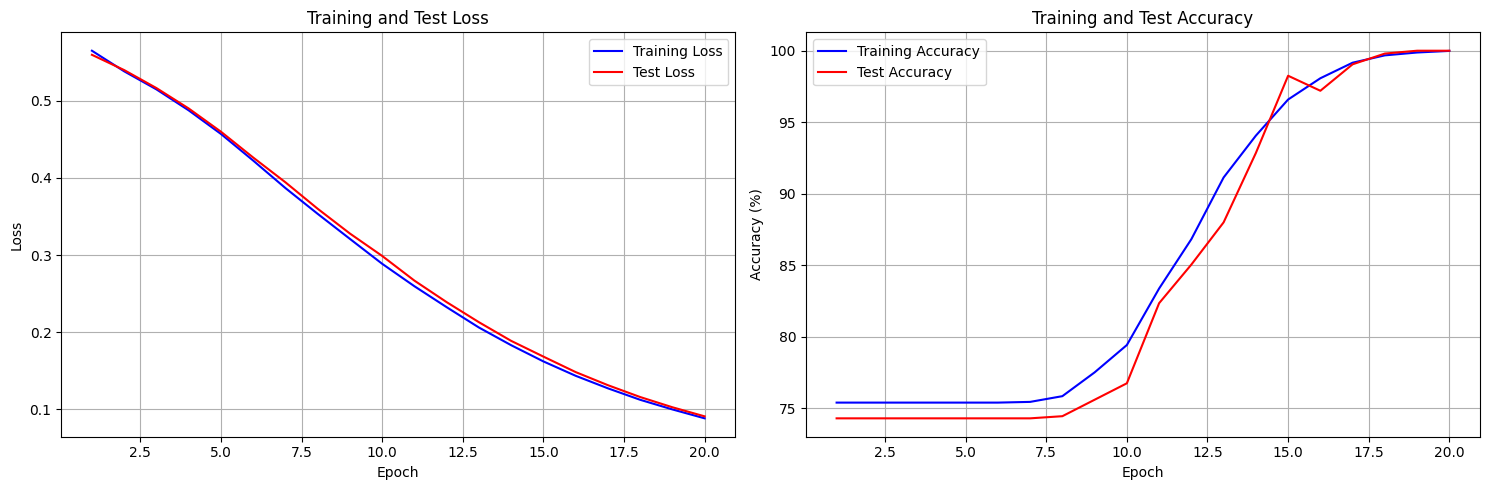

In [74]:
# model = nn.Sequential(
#     nn.Linear(256, 128),
#     nn.ReLU(),
#     nn.Linear(128, 1),
# )

class BinaryMLP(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128):
        super(BinaryMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x):
        return self.model(x.float()).squeeze(-1)

model = BinaryMLP(input_dim=256, hidden_dim=128)

model, history = train_model(model, train_loader, test_loader, input_dim=256, learning_rate=1e-4, num_epochs=20)
plot_training_history(history)


In [75]:
# Train the model
print("Starting training...")
model, history = train_transformer(
    train_loader=train_loader,
    test_loader=test_loader,
    input_dim=triplet_x.shape[1],
    learning_rate=1e-5,
    num_epochs=15,
    d_model=128,
    nhead=8,
    num_layers=4
)

# Plot training history
plot_training_history(history)

Starting training...
Training on device: cuda
Model parameters: 834,433

Epoch 1/15


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Training: 100%|██████████| 125/125 [00:03<00:00, 32.10it/s]


Train Loss: 0.5803, Train Acc: 75.40%
Test Loss: 0.5681, Test Acc: 74.30%

Epoch 2/15


Training: 100%|██████████| 125/125 [00:03<00:00, 32.45it/s]


...

Train Loss: 0.5581, Train Acc: 75.40%
Test Loss: 0.5683, Test Acc: 74.30%

Epoch 10/15


Training: 100%|██████████| 125/125 [00:03<00:00, 32.00it/s]


Train Loss: 0.5580, Train Acc: 75.40%
Test Loss: 0.5685, Test Acc: 74.30%

Epoch 11/15


Training:  74%|███████▍  | 93/125 [00:02<00:01, 31.48it/s]


KeyboardInterrupt: 

In [29]:
model.positional_encoding.detach().cpu()[:, 0]

tensor([-1.3384e-04,  7.1565e-04, -8.8885e-05, -3.6537e-03,  5.7424e-04,
         8.2005e-04, -3.3882e-04,  6.9134e-04, -3.4454e-04, -1.2565e-04,
         2.9033e-04, -3.8904e-04,  2.8983e-04,  8.7235e-04,  1.6745e-04,
         3.1607e-03,  5.0753e-04,  3.9295e-04,  6.2067e-05,  5.8396e-06,
         2.8667e-04, -3.6540e-04,  8.1993e-04, -2.4797e-03, -1.6495e-04,
         1.1072e-04,  3.2851e-03, -3.1197e-03,  7.5074e-06, -8.4299e-05,
         6.8530e-05, -8.9907e-04,  1.2468e-03,  2.6484e-04,  9.5294e-05,
         1.0674e-03,  2.8366e-04, -3.7986e-06, -3.0453e-03,  1.9808e-04,
         1.0833e-04,  7.1227e-04,  1.5592e-05,  4.4923e-04,  3.8461e-04,
         2.8578e-04,  2.9197e-04, -7.2318e-05,  6.1656e-04,  5.4677e-04,
         2.4010e-04, -5.1948e-04,  1.9495e-04,  1.4792e-04,  3.0279e-04,
         3.9357e-04,  8.5725e-04, -2.6140e-03, -9.6741e-04,  5.6436e-04,
         2.6490e-04, -3.6623e-04, -1.8883e-05,  2.6727e-03,  6.8278e-04,
         4.0287e-05, -4.6695e-05, -1.1066e-04,  5.6

In [19]:
# Evaluate model performance on a few test samples
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Get a batch of test data
test_batch_x, test_batch_y = next(iter(test_loader))
test_batch_x, test_batch_y = test_batch_x.to(device), test_batch_y.to(device)

with torch.no_grad():
    predictions = model(test_batch_x)
    binary_predictions = (predictions > 0.5).float()

# Show some examples
print("Sample predictions vs actual:")
for i in range(min(10, len(test_batch_x))):
    print(f"Sample {i+1}: Predicted={binary_predictions[i].item():.0f}, Actual={test_batch_y[i].item():.0f}, Confidence={predictions[i].item():.3f}")

# Calculate final accuracy
correct = (binary_predictions == test_batch_y).sum().item()
total = len(test_batch_y)
print(f"\nBatch accuracy: {100 * correct / total:.2f}%")

Sample predictions vs actual:
Sample 1: Predicted=1, Actual=0, Confidence=0.728
Sample 2: Predicted=1, Actual=1, Confidence=0.728
Sample 3: Predicted=1, Actual=1, Confidence=0.729
Sample 4: Predicted=1, Actual=0, Confidence=0.729
Sample 5: Predicted=1, Actual=0, Confidence=0.730
Sample 6: Predicted=1, Actual=1, Confidence=0.728
Sample 7: Predicted=1, Actual=1, Confidence=0.727
Sample 8: Predicted=1, Actual=0, Confidence=0.730
Sample 9: Predicted=1, Actual=1, Confidence=0.726
Sample 10: Predicted=1, Actual=1, Confidence=0.729

Batch accuracy: 68.75%
